# Career Path Clustering
## HR Alto Network Employee Attrition Project

This notebook follows the original clustering workflow:
career feature selection → correlation → outlier check → scaling → Elbow → Silhouette → K-Means → profiling → PCA → hierarchical validation → attrition/department comparison.

**Corrections:** robust input paths, numeric `Attrition` handling, automatic CSV/image/report saving, and no hard-coded output directories.

# 1. Libraries

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option("display.max_columns", None)


# 2. Load Feature-Engineered Dataset

In [3]:
candidate_paths = [
    Path("../data/feature_engineered/Palo Alto Networks_feature_engineered.csv"),
    Path("../data/feature_engineered_palo_alto.csv"),
    Path("../data/Palo Alto Networks_feature_engineered.csv"),
    Path("Palo Alto Networks_feature_engineered.csv")
]
data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("Feature-engineered dataset not found. Run Day 4 first.")

df = pd.read_csv(data_path)
print("Dataset:", data_path)
print("Shape:", df.shape)
display(df.head())


Dataset: ../data/feature_engineered/Palo Alto Networks_feature_engineered.csv
Shape: (1470, 38)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio,CareerStage,PromotionGapGroup,RoleDurationGroup,TrainingGroup
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,0.000,0.666667,0.833333,Established,Recent Promotion,Established,No Training
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,0.100,0.700000,0.700000,Established,Recent Promotion,Long Time in Role,Moderate Training
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,0.000,0.000000,0.000000,Early Career,Recent Promotion,New in Role,Moderate Training
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0.375,0.875000,0.000000,Established,Moderate Gap,Long Time in Role,Moderate Training
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,1.000,1.000000,1.000000,Early Career,Moderate Gap,New in Role,Moderate Training


# 3. Basic Validation

In [4]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

cluster_features = [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "JobLevel",
    "PromotionGapRatio",
    "RoleStagnationRatio",
    "ManagerStabilityRatio"
]

missing_features = [c for c in cluster_features if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing required clustering features: {missing_features}")

assert df[cluster_features].isna().sum().sum() == 0


Missing values: 0
Duplicate rows: 0


# 4. Select Career Features

These features describe career progression. `Attrition` is deliberately excluded from clustering so that career groups are discovered independently of the outcome.

In [5]:
X = df[cluster_features].copy()

display(X.head())
print("Number of clustering features:", len(cluster_features))


,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,TrainingTimesLastYear,JobLevel,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio
0,6,4,0,5,8,0,2,0.000,0.666667,0.833333
1,10,7,1,7,10,3,2,0.100,0.700000,0.700000
2,0,0,0,0,7,3,1,0.000,0.000000,0.000000
3,8,7,3,0,8,3,1,0.375,0.875000,0.000000
4,2,2,2,2,6,3,1,1.000,1.000000,1.000000


Number of clustering features: 10


# 5. Feature Correlation Analysis

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,TrainingTimesLastYear,JobLevel,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio
YearsAtCompany,1.00,0.76,0.62,0.77,0.63,0.00,0.53,0.07,0.09,0.10
YearsInCurrentRole,0.76,1.00,0.55,0.71,0.46,-0.01,0.39,0.15,0.52,0.23
YearsSinceLastPromotion,0.62,0.55,1.00,0.51,0.40,-0.00,0.35,0.63,0.14,0.12
YearsWithCurrManager,0.77,0.71,0.51,1.00,0.46,-0.00,0.38,0.13,0.22,0.54
TotalWorkingYears,0.63,0.46,0.40,0.46,1.00,-0.04,0.78,0.05,0.00,0.03
TrainingTimesLastYear,0.00,-0.01,-0.00,-0.00,-0.04,1.00,-0.02,0.00,-0.04,-0.05
JobLevel,0.53,0.39,0.35,0.38,0.78,-0.02,1.00,0.05,-0.01,-0.00
PromotionGapRatio,0.07,0.15,0.63,0.13,0.05,0.00,0.05,1.00,0.34,0.31
RoleStagnationRatio,0.09,0.52,0.14,0.22,0.00,-0.04,-0.01,0.34,1.00,0.49
ManagerStabilityRatio,0.10,0.23,0.12,0.54,0.03,-0.05,-0.00,0.31,0.49,1.00


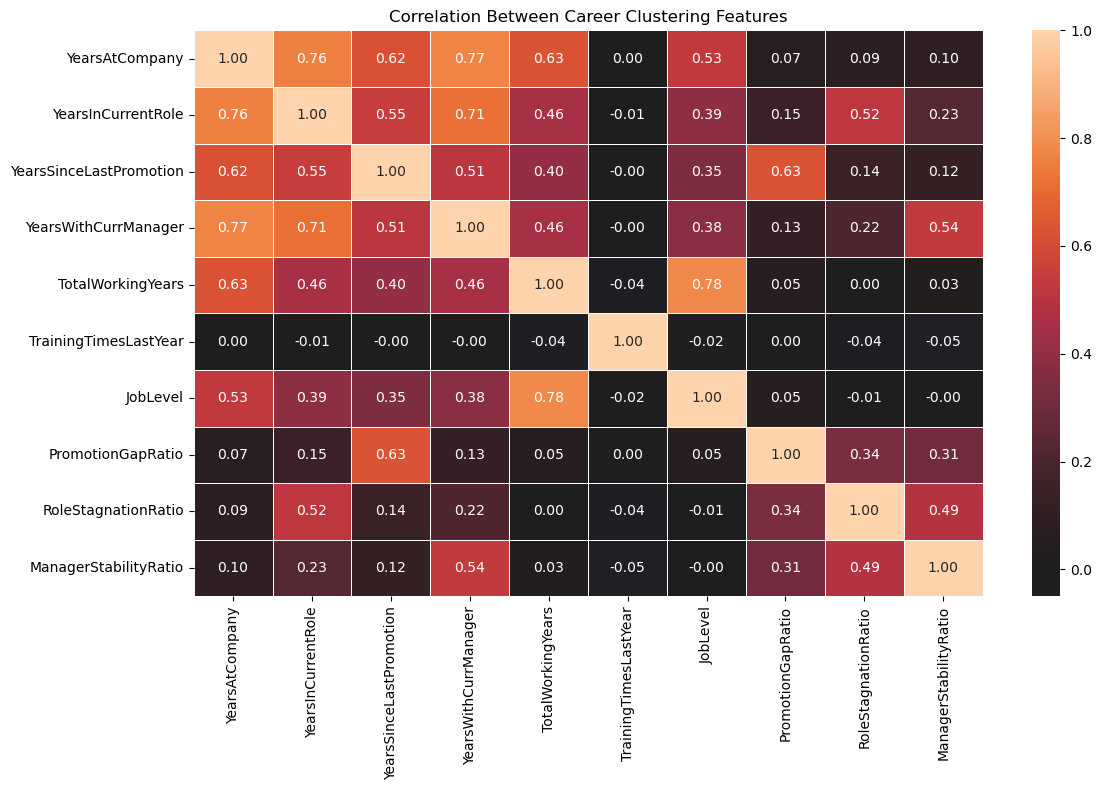

In [6]:
correlation = X.corr().round(2)
display(correlation)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", center=0, linewidths=0.5)
plt.title("Correlation Between Career Clustering Features")
plt.tight_layout()
plt.show()


# 6. Statistical Summary

In [7]:
feature_statistics = X.describe().T.round(2)
display(feature_statistics)


,count,mean,std,min,25%,50%,75%,max
YearsAtCompany,1470.0,7.01,6.13,0.0,3.00,5.00,9.00,40.0
YearsInCurrentRole,1470.0,4.23,3.62,0.0,2.00,3.00,7.00,18.0
YearsSinceLastPromotion,1470.0,2.19,3.22,0.0,0.00,1.00,3.00,15.0
YearsWithCurrManager,1470.0,4.12,3.57,0.0,2.00,3.00,7.00,17.0
TotalWorkingYears,1470.0,11.28,7.78,0.0,6.00,10.00,15.00,40.0
TrainingTimesLastYear,1470.0,2.80,1.29,0.0,2.00,3.00,3.00,6.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.00,3.00,5.0
PromotionGapRatio,1470.0,0.29,0.34,0.0,0.00,0.17,0.50,1.0
RoleStagnationRatio,1470.0,0.58,0.33,0.0,0.35,0.67,0.83,1.0
ManagerStabilityRatio,1470.0,0.56,0.33,0.0,0.33,0.67,0.80,1.0


# 7. Outlier Check

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,YearsAtCompany,-6.00,18.00,104,7.07
1,YearsInCurrentRole,-5.50,14.50,21,1.43
2,YearsSinceLastPromotion,-4.50,7.50,107,7.28
3,YearsWithCurrManager,-5.50,14.50,14,0.95
4,TotalWorkingYears,-7.50,28.50,63,4.29
5,TrainingTimesLastYear,0.50,4.50,238,16.19
6,JobLevel,-2.00,6.00,0,0.00
7,PromotionGapRatio,-0.75,1.25,0,0.00
8,RoleStagnationRatio,-0.37,1.55,0,0.00
9,ManagerStabilityRatio,-0.37,1.50,0,0.00


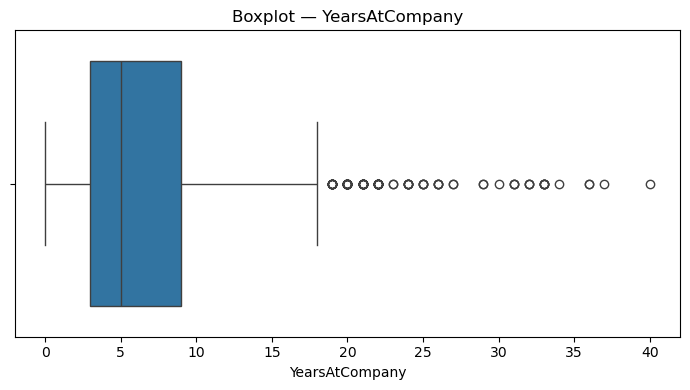

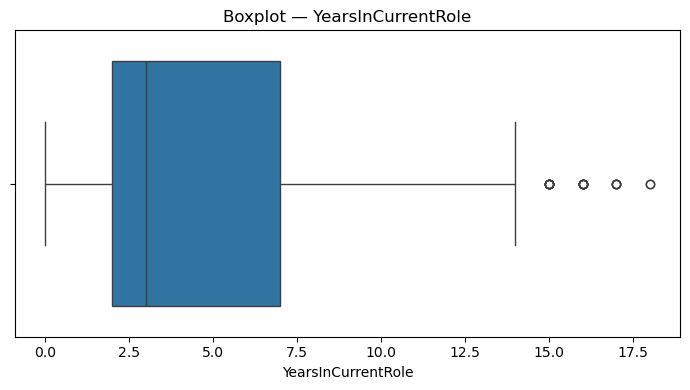

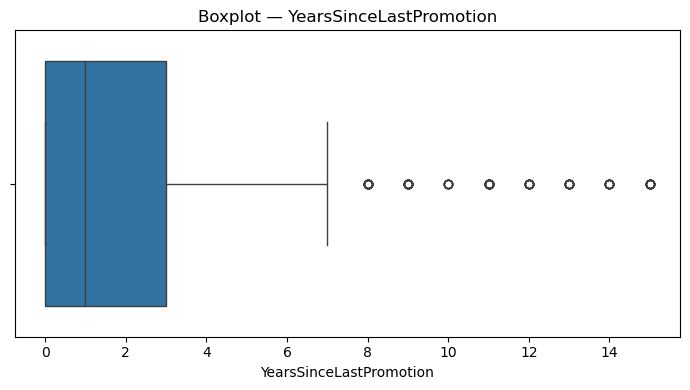

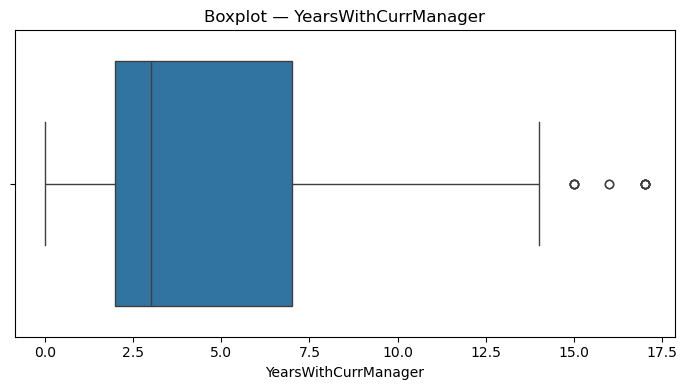

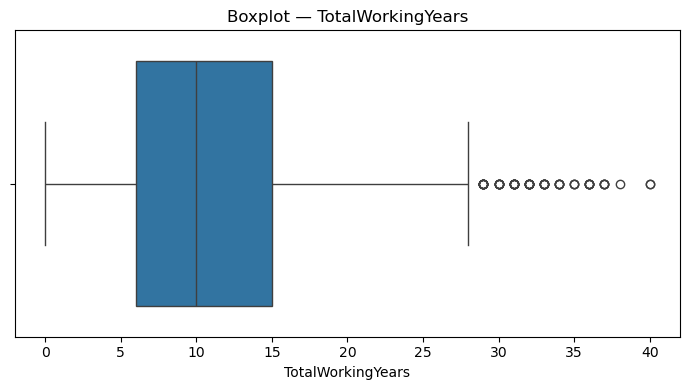

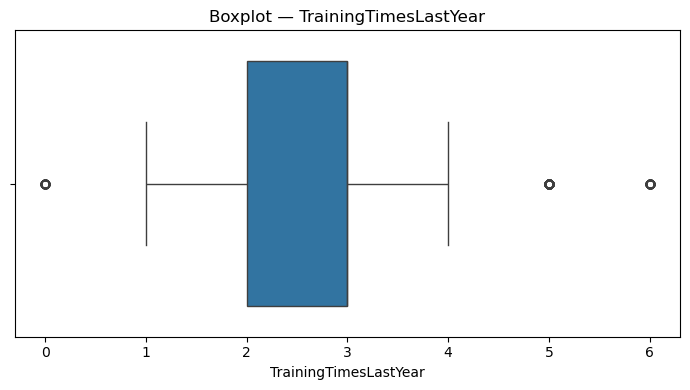

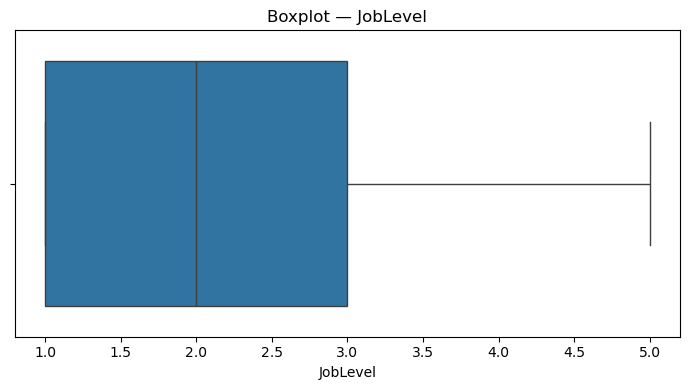

In [8]:
outlier_results = []

for col in cluster_features:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((X[col] < lower) | (X[col] > upper)).sum())

    outlier_results.append({
        "Column": col,
        "Lower_Bound": round(lower, 2),
        "Upper_Bound": round(upper, 2),
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(X) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_results)
display(outlier_summary)

# Visual inspection of the main career variables
for col in [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "JobLevel"
]:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot — {col}")
    plt.tight_layout()
    plt.show()


# 8. Create Feature Matrix

In [9]:
print("Shape of X:", X.shape)
print("Missing values:", int(X.isnull().sum().sum()))
print("All columns numeric:", bool(X.dtypes.apply(pd.api.types.is_numeric_dtype).all()))

assert X.dtypes.apply(pd.api.types.is_numeric_dtype).all()
assert X.isnull().sum().sum() == 0


Shape of X: (1470, 10)
Missing values: 0
All columns numeric: True


# 9. Feature Scaling

In [10]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=cluster_features,
    index=df.index
)

display(X_scaled.head())


,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,TrainingTimesLastYear,JobLevel,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio
0,-0.164613,-0.063296,-0.679146,0.245834,-0.421642,-2.171982,-0.057788,-0.852607,0.266524,0.820959
1,0.488508,0.764998,-0.368715,0.806541,-0.164511,0.155707,-0.057788,-0.558839,0.366970,0.422495
2,-1.144294,-1.167687,-0.679146,-1.155935,-0.550208,0.155707,-0.961486,-0.852607,-1.742398,-1.669441
3,0.161947,0.764998,0.252146,-1.155935,-0.421642,0.155707,-0.961486,0.249022,0.894312,-1.669441
4,-0.817734,-0.615492,-0.058285,-0.595227,-0.678774,0.155707,-0.961486,2.085070,1.270985,1.319039


# 10. Verify Scaling

In [11]:
scaling_summary = X_scaled.describe().T[["mean", "std", "min", "max"]].round(4)
display(scaling_summary)


,mean,std,min,max
YearsAtCompany,-0.0,1.0003,-1.1443,5.3869
YearsInCurrentRole,0.0,1.0003,-1.1677,3.8021
YearsSinceLastPromotion,0.0,1.0003,-0.6791,3.9773
YearsWithCurrManager,-0.0,1.0003,-1.1559,3.6101
TotalWorkingYears,-0.0,1.0003,-1.4502,3.6925
TrainingTimesLastYear,0.0,1.0003,-2.1720,2.4834
JobLevel,-0.0,1.0003,-0.9615,2.6533
PromotionGapRatio,0.0,1.0003,-0.8526,2.0851
RoleStagnationRatio,0.0,1.0003,-1.7424,1.2710
ManagerStabilityRatio,-0.0,1.0003,-1.6694,1.3190


# 11. Find Optimal K — Elbow Method

,K,Inertia
0,2,10627.819889
1,3,9047.473086
2,4,7952.587333
3,5,7131.128154
4,6,6486.250003
5,7,5966.948751


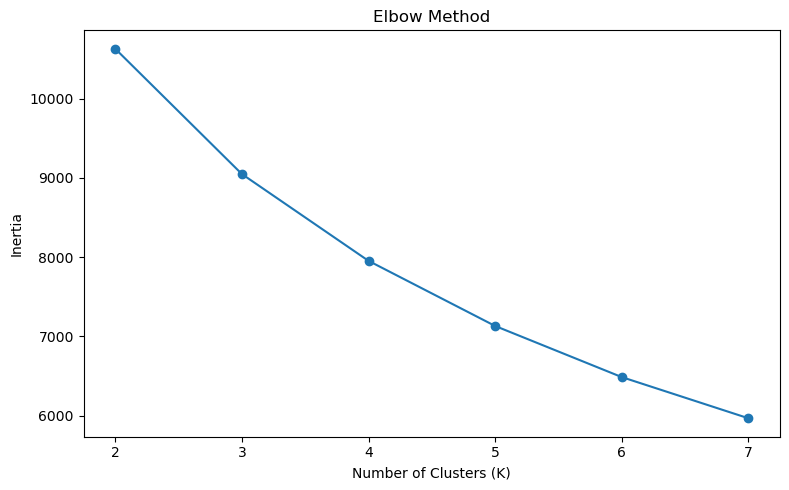

In [12]:
k_values = range(2, 8)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias
})

display(elbow_results)

plt.figure(figsize=(8, 5))
plt.plot(elbow_results["K"], elbow_results["Inertia"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


# 11.2 Silhouette Score

,K,Silhouette_Score
0,2,0.274540
1,3,0.220783
2,4,0.227527
3,5,0.223099
4,6,0.237783
5,7,0.244939


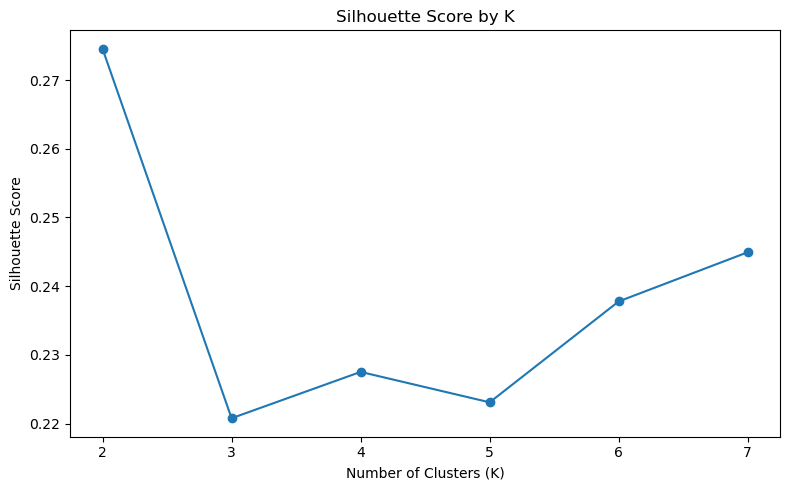

In [13]:
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette_Score": silhouette_scores
})

display(silhouette_results)

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette_Score"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


# 12. Choose Final K

The original notebook uses **K = 4**. Keep this as the initial project decision after considering the Elbow, Silhouette Score, cluster sizes, and business interpretability.

Change `selected_k` only when the analysis supports another value.

In [14]:
selected_k = 4

if selected_k not in list(k_values):
    raise ValueError("selected_k must be one of the tested K values.")

print("Selected K:", selected_k)


Selected K: 4


# 13. Train Final K-Means Model

In [15]:
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

df["CareerCluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")
display(df[["CareerCluster"] + cluster_features].head(10))


K-Means clustering completed.


,CareerCluster,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,TrainingTimesLastYear,JobLevel,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio
0,3,6,4,0,5,8,0,2,0.000000,0.666667,0.833333
1,3,10,7,1,7,10,3,2,0.100000,0.700000,0.700000
2,1,0,0,0,0,7,3,1,0.000000,0.000000,0.000000
3,3,8,7,3,0,8,3,1,0.375000,0.875000,0.000000
4,2,2,2,2,2,6,3,1,1.000000,1.000000,1.000000
5,2,7,7,3,6,8,2,1,0.428571,1.000000,0.857143
6,1,1,0,0,0,12,3,1,0.000000,0.000000,0.000000
7,1,1,0,0,0,1,2,1,0.000000,0.000000,0.000000
8,3,9,7,1,8,10,2,3,0.111111,0.777778,0.888889
9,2,7,7,7,7,17,3,2,1.000000,1.000000,1.000000


# 14. Cluster Sizes

In [16]:
cluster_sizes = (
    df["CareerCluster"]
    .value_counts()
    .sort_index()
    .rename_axis("CareerCluster")
    .reset_index(name="Employee_Count")
)

cluster_sizes["Percentage"] = (
    cluster_sizes["Employee_Count"] / len(df) * 100
).round(2)

display(cluster_sizes)


,CareerCluster,Employee_Count,Percentage
0,0,241,16.39
1,1,259,17.62
2,2,291,19.80
3,3,679,46.19


# 15. Cluster Profiling

In [17]:
cluster_profile = (
    df.groupby("CareerCluster", observed=True)[cluster_features]
    .mean()
    .round(2)
)

display(cluster_profile)


,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,TrainingTimesLastYear,JobLevel,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio
CareerCluster,,,,,,,,,,
0,17.79,9.37,6.20,9.15,21.96,2.78,3.36,0.37,0.58,0.56
1,1.73,0.46,0.22,0.19,7.60,3.01,1.66,0.08,0.14,0.04
2,5.62,4.31,4.35,4.12,9.37,2.84,1.87,0.83,0.81,0.78
3,5.79,3.80,0.59,3.85,9.71,2.71,1.84,0.11,0.64,0.66


# 16. Cluster Profile Heatmap

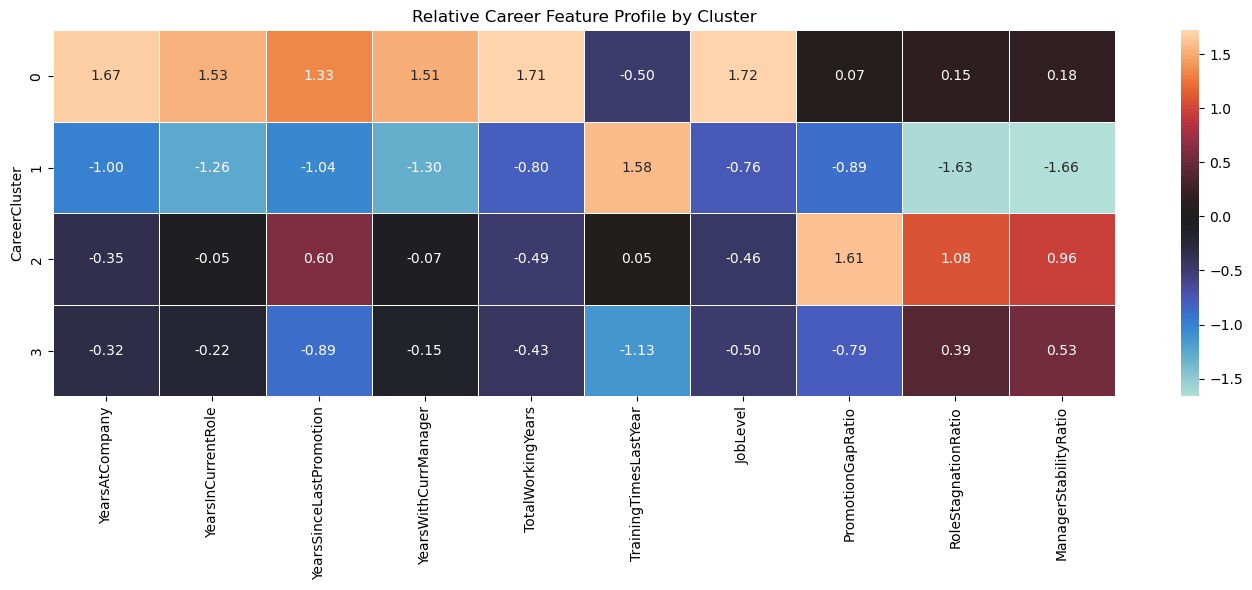

In [18]:
profile_z = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std(ddof=0)

profile_z = profile_z.replace([np.inf, -np.inf], 0).fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(profile_z, annot=True, fmt=".2f", center=0, linewidths=0.5)
plt.title("Relative Career Feature Profile by Cluster")
plt.tight_layout()
plt.show()


# 17. Cluster Naming Framework

Do not invent business names before reviewing `cluster_profile`.

Possible descriptive names include:
- Early Career Employees
- Fast Career Progressors
- Stable Career Employees
- Promotion-Stagnated Employees

The notebook initially keeps neutral names to avoid unsupported conclusions.

In [19]:
cluster_names = {
    cluster: f"Career Cluster {cluster}"
    for cluster in sorted(df["CareerCluster"].unique())
}

df["CareerClusterName"] = df["CareerCluster"].map(cluster_names)

display(
    df[["CareerCluster", "CareerClusterName"]]
    .drop_duplicates()
    .sort_values("CareerCluster")
)


,CareerCluster,CareerClusterName
18,0,Career Cluster 0
2,1,Career Cluster 1
4,2,Career Cluster 2
0,3,Career Cluster 3


# 18. PCA Visualization

,Component,Explained_Variance_Ratio
0,PC1,0.403383
1,PC2,0.182050


Total explained variance: 0.5854


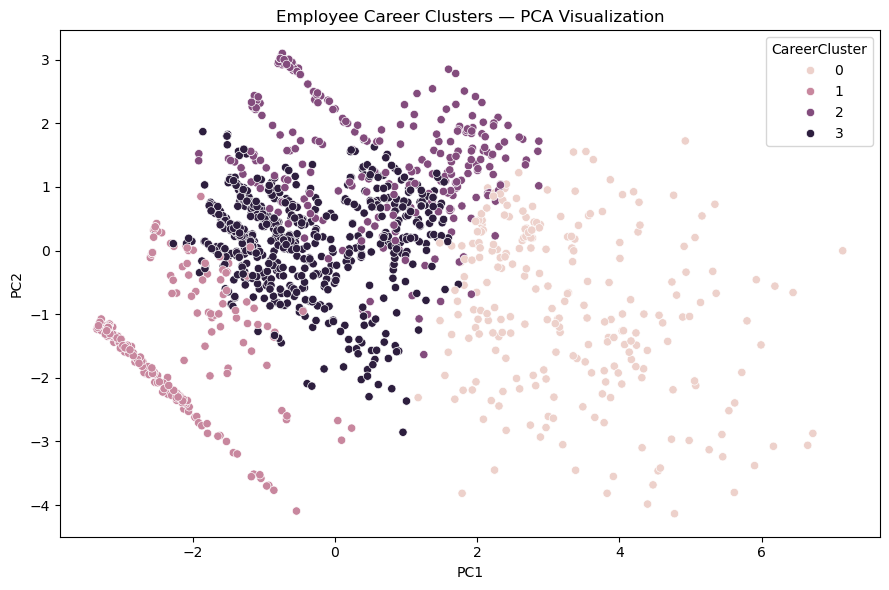

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df.index
)
pca_df["CareerCluster"] = df["CareerCluster"].values

explained_variance = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_
})

display(explained_variance)
print("Total explained variance:",
      round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="CareerCluster"
)
plt.title("Employee Career Clusters — PCA Visualization")
plt.tight_layout()
plt.show()


# 19. Hierarchical Clustering — Dendrogram

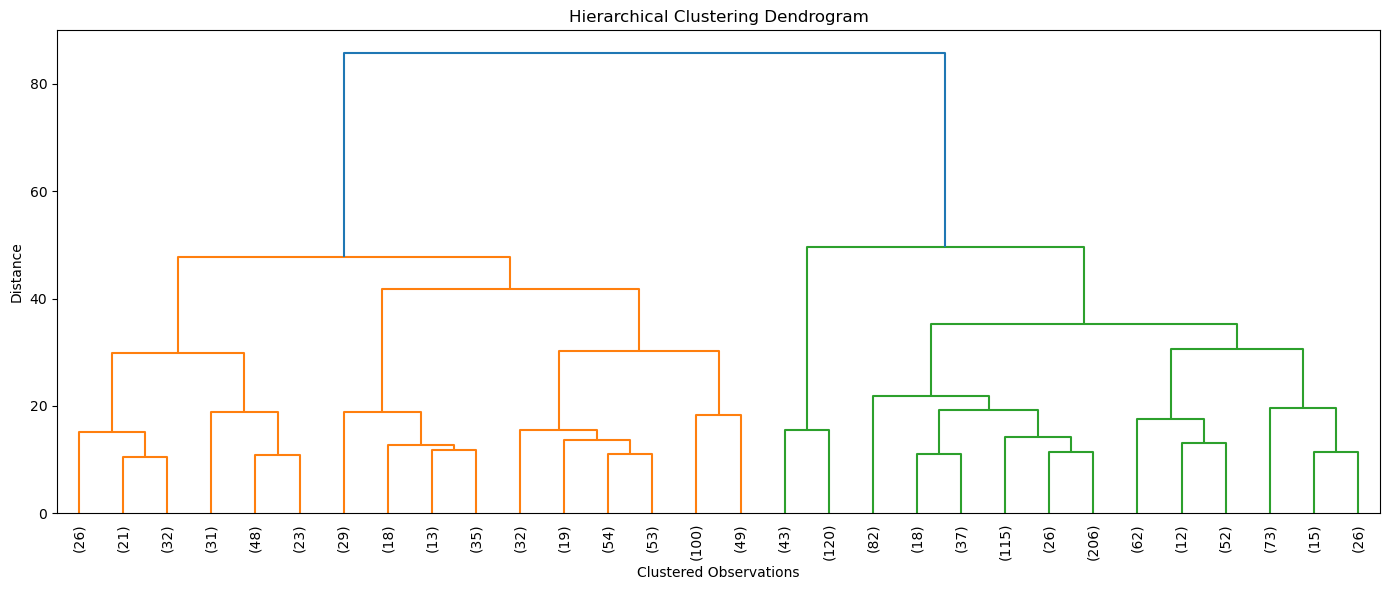

In [21]:
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered Observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


# 19.2 Agglomerative Clustering

In [22]:
hierarchical = AgglomerativeClustering(
    n_clusters=selected_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical clustering silhouette score:",
    round(hierarchical_silhouette, 4)
)


Hierarchical clustering silhouette score: 0.1795


# 20. Compare K-Means and Hierarchical Clustering

In [23]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    df["CareerCluster"]
)

clustering_comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical"],
    "Silhouette_Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

display(clustering_comparison)


,Method,Silhouette_Score
0,K-Means,0.227527
1,Hierarchical,0.179541


# 21. Career Clusters vs Attrition

**Correction:** this project stores `Attrition` as `0/1`, so comparing against `"Yes"` would incorrectly return zero. We use numeric `1` to count employees who left.

In [24]:
cluster_attrition = (
    df.groupby("CareerCluster", observed=True)
    .agg(
        Employee_Count=("Attrition", "size"),
        Attrition_Count=("Attrition", "sum")
    )
    .reset_index()
)

cluster_attrition["Attrition_Rate"] = (
    cluster_attrition["Attrition_Count"]
    / cluster_attrition["Employee_Count"]
    * 100
).round(2)

display(cluster_attrition)


,CareerCluster,Employee_Count,Attrition_Count,Attrition_Rate
0,0,241,19,7.88
1,1,259,82,31.66
2,2,291,56,19.24
3,3,679,80,11.78


# 22. Cluster vs Department

In [25]:
cluster_department = pd.crosstab(
    df["CareerCluster"],
    df["Department"]
)

display(cluster_department)


Department,Human Resources,Research & Development,Sales
CareerCluster,,,
0,9,156,76
1,9,171,79
2,13,179,99
3,32,455,192


# 23. Potential Career-Stagnation Cluster

In [26]:
stagnation_columns = [
    "YearsSinceLastPromotion",
    "PromotionGapRatio",
    "YearsInCurrentRole",
    "RoleStagnationRatio"
]

stagnation_profile = cluster_profile[stagnation_columns].copy()
display(stagnation_profile)

stagnation_profile["Stagnation_Signal_Average"] = (
    stagnation_profile["PromotionGapRatio"].rank(pct=True)
    + stagnation_profile["RoleStagnationRatio"].rank(pct=True)
    + stagnation_profile["YearsSinceLastPromotion"].rank(pct=True)
    + stagnation_profile["YearsInCurrentRole"].rank(pct=True)
) / 4

stagnation_profile = stagnation_profile.sort_values(
    "Stagnation_Signal_Average",
    ascending=False
)

display(stagnation_profile)


,YearsSinceLastPromotion,PromotionGapRatio,YearsInCurrentRole,RoleStagnationRatio
CareerCluster,,,,
0,6.20,0.37,9.37,0.58
1,0.22,0.08,0.46,0.14
2,4.35,0.83,4.31,0.81
3,0.59,0.11,3.80,0.64


,YearsSinceLastPromotion,PromotionGapRatio,YearsInCurrentRole,RoleStagnationRatio,Stagnation_Signal_Average
CareerCluster,,,,,
2,4.35,0.83,4.31,0.81,0.8750
0,6.20,0.37,9.37,0.58,0.8125
3,0.59,0.11,3.80,0.64,0.5625
1,0.22,0.08,0.46,0.14,0.2500


# 24. Key Business Insights

In [27]:
highest_promotion_cluster = cluster_profile["PromotionGapRatio"].idxmax()
highest_role_cluster = cluster_profile["RoleStagnationRatio"].idxmax()
highest_attrition_cluster = cluster_attrition.loc[
    cluster_attrition["Attrition_Rate"].idxmax(), "CareerCluster"
]
largest_cluster = cluster_sizes.loc[
    cluster_sizes["Employee_Count"].idxmax(), "CareerCluster"
]
highest_stagnation_signal_cluster = stagnation_profile.index[0]

business_insights = pd.DataFrame([
    {
        "Insight_Area": "Promotion Gap",
        "Finding": f"Career Cluster {highest_promotion_cluster} has the highest average PromotionGapRatio.",
        "Interpretation": "Investigate promotion progression within this cluster."
    },
    {
        "Insight_Area": "Role Duration",
        "Finding": f"Career Cluster {highest_role_cluster} has the highest average RoleStagnationRatio.",
        "Interpretation": "Investigate role progression and internal mobility."
    },
    {
        "Insight_Area": "Attrition",
        "Finding": f"Career Cluster {highest_attrition_cluster} has the highest attrition rate.",
        "Interpretation": "Compare this group's career characteristics with retention factors."
    },
    {
        "Insight_Area": "Cluster Size",
        "Finding": f"Career Cluster {largest_cluster} is the largest employee group.",
        "Interpretation": "This represents the most common career pattern."
    },
    {
        "Insight_Area": "Stagnation Signal",
        "Finding": f"Career Cluster {highest_stagnation_signal_cluster} ranks highest on the descriptive stagnation signal.",
        "Interpretation": "Use this group for deeper career-development investigation."
    }
])

display(business_insights)


,Insight_Area,Finding,Interpretation
0,Promotion Gap,Career Cluster 2 has the highest average Promo...,Investigate promotion progression within this ...
1,Role Duration,Career Cluster 2 has the highest average RoleS...,Investigate role progression and internal mobi...
2,Attrition,Career Cluster 1 has the highest attrition rate.,Compare this group's career characteristics wi...
3,Cluster Size,Career Cluster 3 is the largest employee group.,This represents the most common career pattern.
4,Stagnation Signal,Career Cluster 2 ranks highest on the descript...,Use this group for deeper career-development i...


# 25. Automatically Save All Outputs

In [28]:
output_dir = Path("../outputs/day_5")
tables_dir = output_dir / "tables"
images_dir = output_dir / "images"
reports_dir = output_dir / "reports"
cluster_dir = Path("../data/clustering")

for folder in [tables_dir, images_dir, reports_dir, cluster_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# Final clustered dataset
clustered_path = cluster_dir / "Palo Alto Networks_clustered.csv"
df.to_csv(clustered_path, index=False)

# Tables
tables = {
    "cluster_features": pd.DataFrame({"Feature": cluster_features}),
    "feature_statistics": feature_statistics,
    "outlier_summary": outlier_summary,
    "scaling_summary": scaling_summary,
    "elbow_results": elbow_results,
    "silhouette_results": silhouette_results,
    "cluster_sizes": cluster_sizes,
    "cluster_profile": cluster_profile.reset_index(),
    "pca_explained_variance": explained_variance,
    "pca_coordinates": pca_df,
    "clustering_comparison": clustering_comparison,
    "cluster_attrition": cluster_attrition,
    "cluster_department": cluster_department.reset_index(),
    "stagnation_profile": stagnation_profile.reset_index(),
    "business_insights": business_insights
}

for name, table in tables.items():
    table.to_csv(tables_dir / f"{name}.csv", index=False)

X_scaled.to_csv(tables_dir / "scaled_features.csv", index=False)

# Figures
def save_fig(filename):
    plt.savefig(images_dir / filename, dpi=150, bbox_inches="tight")
    plt.close()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", center=0, linewidths=0.5)
plt.title("Correlation Between Career Clustering Features")
plt.tight_layout()
save_fig("01_feature_correlation.png")

plt.figure(figsize=(8, 5))
plt.plot(elbow_results["K"], elbow_results["Inertia"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
save_fig("02_elbow_method.png")

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette_Score"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(list(k_values))
plt.tight_layout()
save_fig("03_silhouette_score.png")

plt.figure(figsize=(14, 6))
sns.heatmap(profile_z, annot=True, fmt=".2f", center=0, linewidths=0.5)
plt.title("Relative Career Feature Profile by Cluster")
plt.tight_layout()
save_fig("04_cluster_profile_heatmap.png")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="CareerCluster"
)
plt.title("Employee Career Clusters — PCA Visualization")
plt.tight_layout()
save_fig("05_pca_clusters.png")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered Observations")
plt.ylabel("Distance")
plt.tight_layout()
save_fig("06_hierarchical_dendrogram.png")

# Report
report = (
    "# Career Path Clustering Report\n\n"
    f"Input dataset: {data_path}\n\n"
    f"Rows: {len(df)}\n\n"
    f"Clustering features: {len(cluster_features)}\n\n"
    f"Selected K: {selected_k}\n\n"
    "## Methods\n"
    "- StandardScaler\n"
    "- K-Means\n"
    "- Elbow Method\n"
    "- Silhouette Score\n"
    "- PCA visualization\n"
    "- Hierarchical / Agglomerative Clustering\n\n"
    "## Validation\n"
    f"K-Means silhouette score: {kmeans_silhouette:.4f}\n\n"
    f"Hierarchical silhouette score: {hierarchical_silhouette:.4f}\n\n"
    "## Interpretation\n"
    f"Highest PromotionGapRatio cluster: {highest_promotion_cluster}\n\n"
    f"Highest RoleStagnationRatio cluster: {highest_role_cluster}\n\n"
    f"Highest attrition-rate cluster: {highest_attrition_cluster}\n\n"
    f"Largest cluster: {largest_cluster}\n\n"
    f"Highest descriptive stagnation-signal cluster: {highest_stagnation_signal_cluster}\n\n"
    "## Important Note\n"
    "Clusters are created without Attrition. Attrition is compared after clustering. "
    "A high stagnation signal is not proof that an employee is dissatisfied or will leave.\n"
)

(reports_dir / "day_5_clustering_report.md").write_text(
    report,
    encoding="utf-8"
)

print("Clustered dataset:", clustered_path)
print("Tables:", tables_dir)
print("Images:", images_dir)
print("Report:", reports_dir / "day_5_clustering_report.md")


Clustered dataset: ../data/clustering/Palo Alto Networks_clustered.csv
Tables: ../outputs/day_5/tables
Images: ../outputs/day_5/images
Report: ../outputs/day_5/reports/day_5_clustering_report.md
